# 02 - Exploratory Data Analysis (EDA)

Load the merged dataset, explore distributions, time-series patterns, correlations, and discuss data leakage risks.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_merged_data
from src.utils import get_data_dir

# Load data (use synthetic if merged_data.csv missing)
try:
    df = load_merged_data()
except FileNotFoundError:
    from src.synthetic_data import generate_synthetic_dataset
    df = generate_synthetic_dataset()
    get_data_dir().mkdir(parents=True, exist_ok=True)
    df.to_csv(get_data_dir() / 'merged_data.csv', index=False)

df['date'] = pd.to_datetime(df['date'])
print(df.shape)
df.head()

(1300, 19)


,field_id,date,B2,B3,B4,B8,B11,B12,NDVI,EVI,NDRE,SAVI,temperature,precipitation,solar_rad,soil_pH,soil_OC,soil_clay,yield
0,field_0,2023-04-01,0.084292,0.163191,0.085214,0.229573,0.228003,0.158474,0.215954,0.325524,0.587517,0.265761,19.070676,14.054420,117.442823,6.37454,1.047901,27.840633,8.0
1,field_0,2023-04-11,0.082234,0.153541,0.099689,0.200623,0.213554,0.153326,0.167704,0.213482,0.483869,0.189177,16.675105,14.134216,112.043217,6.37454,1.047901,27.840633,8.0
2,field_0,2023-04-21,0.072321,0.218811,0.001783,0.396434,0.231246,0.171154,0.494057,1.140980,0.993724,0.659058,18.673057,13.917463,116.641020,6.37454,1.047901,27.840633,8.0
3,field_0,2023-05-01,0.071957,0.205144,0.022285,0.355431,0.242236,0.182996,0.425718,0.877197,0.915914,0.569341,15.944022,12.838239,115.884329,6.37454,1.047901,27.840633,8.0
4,field_0,2023-05-11,0.082317,0.175107,0.067339,0.265322,0.232957,0.153855,0.275536,0.470500,0.698281,0.356656,16.749665,13.606272,116.930645,6.37454,1.047901,27.840633,8.0


## 1. Distributions

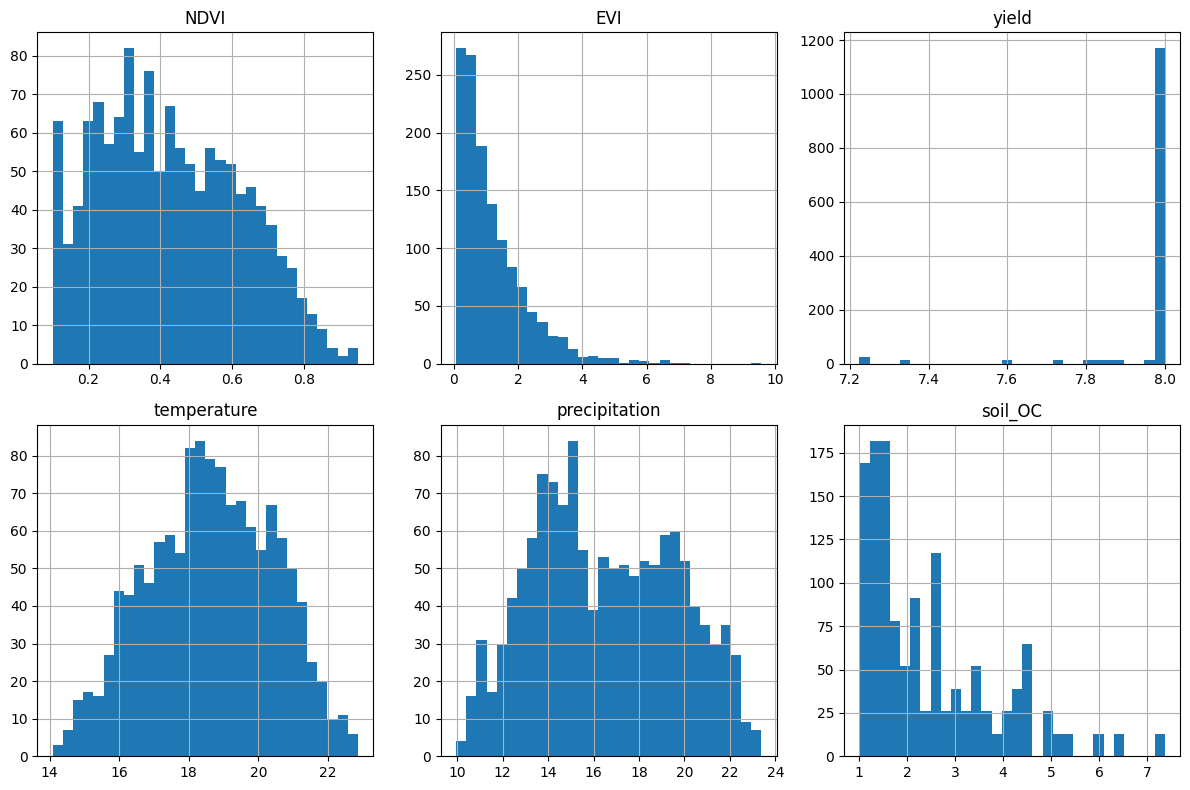

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, col in zip(axes.flat, ['NDVI', 'EVI', 'yield', 'temperature', 'precipitation', 'soil_OC']):
    if col in df.columns:
        df[col].hist(ax=ax, bins=30)
        ax.set_title(col)
plt.tight_layout()
plt.savefig('../reports/figures/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. NDVI Time-Series for Sample Fields

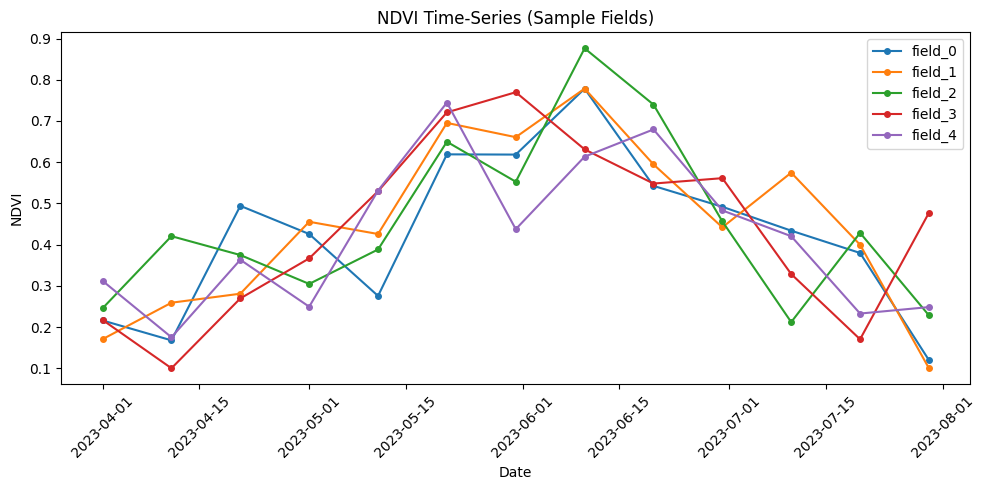

In [3]:
sample_fields = df['field_id'].unique()[:5]
fig, ax = plt.subplots(figsize=(10, 5))
for fid in sample_fields:
    grp = df[df['field_id'] == fid].sort_values('date')
    ax.plot(grp['date'], grp['NDVI'], label=fid, marker='o', markersize=4)
ax.set_xlabel('Date')
ax.set_ylabel('NDVI')
ax.set_title('NDVI Time-Series (Sample Fields)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/eda_ndvi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Correlation Heatmap & NDVI–Yield Interaction

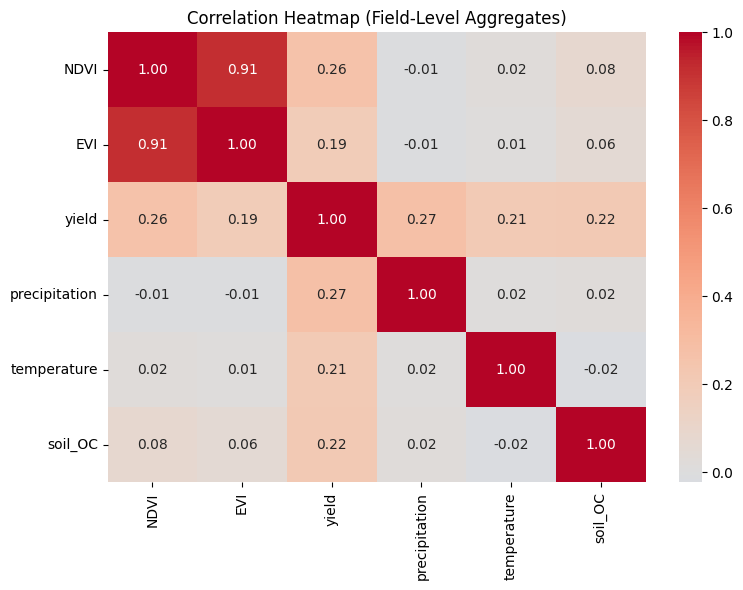

In [4]:
agg = df.groupby('field_id').agg({
    'NDVI': 'max', 'EVI': 'max', 'yield': 'first',
    'precipitation': 'sum', 'temperature': 'mean', 'soil_OC': 'first'
}).reset_index()

plt.figure(figsize=(8, 6))
numeric = agg.select_dtypes(include=[np.number])
sns.heatmap(numeric.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (Field-Level Aggregates)')
plt.tight_layout()
plt.savefig('../reports/figures/eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

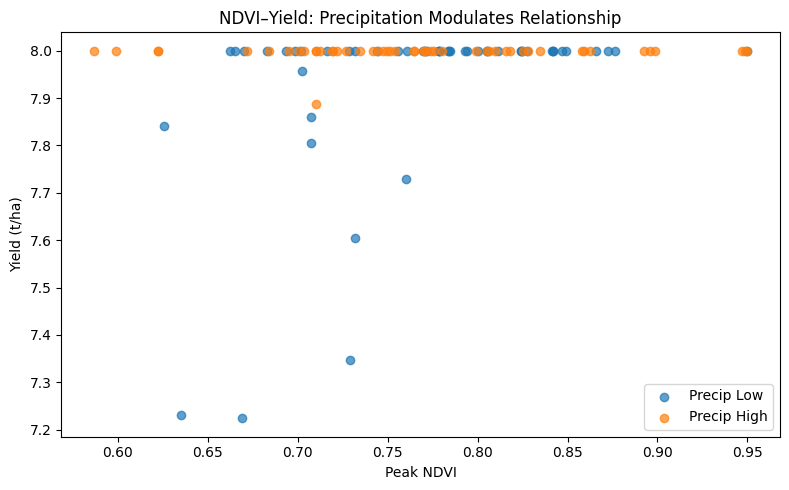

In [5]:
# Interaction: NDVI peak vs yield, stratified by precipitation
agg['precip_high'] = agg['precipitation'] > agg['precipitation'].median()
plt.figure(figsize=(8, 5))
for label, sub in agg.groupby('precip_high'):
    plt.scatter(sub['NDVI'], sub['yield'], label=f'Precip {"High" if label else "Low"}', alpha=0.7)
plt.xlabel('Peak NDVI')
plt.ylabel('Yield (t/ha)')
plt.title('NDVI–Yield: Precipitation Modulates Relationship')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/eda_ndvi_yield_interaction.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Missing Data & Outliers

In [6]:
print('Missing values:')
print(df.isnull().sum())
print('\nOutliers (IQR):')
for col in ['NDVI', 'yield']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5*iqr) | (df[col] > q3 + 1.5*iqr)).sum()
    print(f'  {col}: {n_out}')

Missing values:
field_id         0
date             0
B2               0
B3               0
B4               0
B8               0
B11              0
B12              0
NDVI             0
EVI              0
NDRE             0
SAVI             0
temperature      0
precipitation    0
solar_rad        0
soil_pH          0
soil_OC          0
soil_clay        0
yield            0
dtype: int64

Outliers (IQR):
  NDVI: 0
  yield: 130


## 5. Data Leakage Prevention

- **Target alignment**: Yield labels are for the same year as satellite/weather data.
- **Temporal split**: We use data from April–July (1 month before harvest) only.
- **No future weather**: Cumulative precip and GDD are computed up to prediction date only.